<a href="https://colab.research.google.com/github/AufaNanda/Honor-Of-King---Sentiment-Analysis/blob/main/Honor_Of_Kings_sentiment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import library

In [142]:
!pip install google-play-scraper
!pip install sastrawi

In [143]:

from google_play_scraper import app, reviews, Sort, reviews_all

import pandas as pd
pd.options.mode.chained_assignment = None
import numpy as np
seed = 0
np.random.seed(seed)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score

import datetime as dt
import re
import string
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

from sklearn.feature_extraction.text import TfidfVectorizer

from wordcloud import WordCloud

import csv

import requests
from io import StringIO

import nltk
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

# Scrap the data from google play store

In [144]:
Scrap_HOK = reviews_all(
    "com.levelinfinite.sgameGlobal",
    lang="id",
    country="id",
    sort=Sort.MOST_RELEVANT
)

In [145]:
with open('HOK_comment.csv', mode='w', newline='', encoding='utf-8') as file:
    writer = csv.writer(file)
    writer.writerow(['Review'])
    for review in Scrap_HOK:
        writer.writerow([review['content']])

In [146]:
df = pd.DataFrame(Scrap_HOK)

df.to_csv('Hok_playstore.csv', index=False)


df = pd.DataFrame(Scrap_HOK)


jumlah_ulasan, jumlah_kolom = df.shape

In [147]:
df.shape

(121500, 11)

In [148]:
df

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,c3b67d9c-9b82-4d84-8e26-3fd1472e650a,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Min, ini kenapa dah? aku cek Jaringan aman, di...",3,1,11.4.1.11,2026-08-16 21:54:28,Kami sangat memahami perasaan kalian. Jangan k...,2026-08-17 04:26:13,11.4.1.11
1,17fc21b8-8d1d-4520-a70c-7dea7005ceae,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"saya mengubah ulasan, karena entah kenapa akhi...",1,2,11.4.1.11,2026-08-11 12:28:33,"Halo kak,\nMaaf atas pengalaman kurang baik ya...",2026-08-12 03:06:26,11.4.1.11
2,0fed06e3-c350-416a-b92e-6e775e9a468e,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,gamenya terlalu seimbang buat game lebih sulit...,1,1,11.4.1.11,2026-08-16 15:42:21,Kami sangat memahami perasaan Anda. Kemampuan ...,2026-08-17 03:28:13,11.4.1.11
3,0ffc4b6e-2749-46e0-aaa6-07d96d73251c,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Game Nya Sangat Bagus, Event Nya Banyak dan se...",5,1,11.4.1.11,2026-08-09 14:54:08,None,NaT,11.4.1.11
4,f17e7c0e-37cc-43b9-abe1-f946b019ef36,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"gamenya bagusss bangett, aku suka grafiknya da...",5,1,11.4.1.11,2026-08-14 06:09:40,None,NaT,11.4.1.11
...,...,...,...,...,...,...,...,...,...,...,...
121495,753bd856-c6bc-4fb8-bec7-13d120809a18,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,seru,5,0,10.2.1.3,2025-01-20 08:33:50,None,NaT,10.2.1.3
121496,119aeaef-ffe0-4931-bee2-13bbb001f439,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,bgus,5,0,10.2.1.3,2025-01-21 15:50:31,None,NaT,10.2.1.3
121497,273aa4d0-68cb-40ed-b7dc-a1b00c6cc219,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,sseru,5,0,10.2.1.3,2025-01-20 14:05:30,None,NaT,10.2.1.3
121498,e4d5aa43-f4aa-4d01-ab55-f59410c587ea,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,good,5,0,10.2.1.3,2025-01-19 22:23:29,None,NaT,10.2.1.3


In [149]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121500 entries, 0 to 121499
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   reviewId              121500 non-null  object        
 1   userName              121500 non-null  object        
 2   userImage             121500 non-null  object        
 3   content               121500 non-null  object        
 4   score                 121500 non-null  int64         
 5   thumbsUpCount         121500 non-null  int64         
 6   reviewCreatedVersion  87537 non-null   object        
 7   at                    121500 non-null  datetime64[ns]
 8   replyContent          29253 non-null   object        
 9   repliedAt             29253 non-null   datetime64[ns]
 10  appVersion            87537 non-null   object        
dtypes: datetime64[ns](2), int64(2), object(7)
memory usage: 10.2+ MB


In [150]:
df.isnull().sum()

,0
reviewId,0
userName,0
userImage,0
content,0
score,0
thumbsUpCount,0
reviewCreatedVersion,33963
at,0
replyContent,92247
repliedAt,92247


# All preprocessing function

In [152]:
def cleaningText(text):
    text = re.sub(r'@[A-Za-z0-9]+', '', text)
    text = re.sub(r'#[A-Za-z0-9]+', '', text)
    text = re.sub(r'RT[\s]', '', text)
    text = re.sub(r"http\S+", '', text)
    text = re.sub(r'[0-9]+', '', text)
    text = re.sub(r'[^\w\s]', '', text)

    text = text.replace('\n', ' ')
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = text.strip(' ')
    return text

In [153]:
def casefoldingText(text):
    text = text.lower()
    return text

In [154]:
def tokenizingText(text):
    text = word_tokenize(text)
    return text

In [155]:
def filteringText(text):
    listStopwords = set(stopwords.words('indonesian'))
    listStopwords1 = set(stopwords.words('english'))
    listStopwords.update(listStopwords1)
    listStopwords.update(['iya','yaa','gak','nya','na','sih','ku',"di","ga","ya","gaa","loh","kah","woi","woii","woy"])
    filtered = []
    for txt in text:
        if txt not in listStopwords:
            filtered.append(txt)
    text = filtered
    return text

In [156]:
def stemmingText(text):

    factory = StemmerFactory()
    stemmer = factory.create_stemmer()


    words = text.split()


    stemmed_words = [stemmer.stem(word) for word in words]


    stemmed_text = ' '.join(stemmed_words)

    return stemmed_text

In [157]:
def toSentence(list_words):
    sentence = ' '.join(word for word in list_words)
    return sentence

In [158]:
slangwords = {"@": "di", "abis": "habis", "wtb": "beli", "masi": "masih", "wts": "jual", "wtt": "tukar", "bgt": "banget", "maks": "maksimal"}
def fix_slangwords(text):
    words = text.split()
    fixed_words = []

    for word in words:
        if word.lower() in slangwords:
            fixed_words.append(slangwords[word.lower()])
        else:
            fixed_words.append(word)

    fixed_text = ' '.join(fixed_words)
    return fixed_text

In [159]:
#Applied all the function the current dataframe

df['text_clean'] = df['content'].apply(cleaningText)


df['text_casefoldingText'] = df['text_clean'].apply(casefoldingText)


df['text_slangwords'] = df['text_casefoldingText'].apply(fix_slangwords)


df['text_tokenizingText'] = df['text_slangwords'].apply(tokenizingText)


df['text_stopword'] = df['text_tokenizingText'].apply(filteringText)


df['text_akhir'] = df['text_stopword'].apply(toSentence)

# Labeling

In [160]:
lexicon_positive = dict()

response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_positive.csv')

if response.status_code == 200:

    reader = csv.reader(StringIO(response.text), delimiter=',')

    for row in reader:

        lexicon_positive[row[0]] = int(row[1])

else:
    print("Failed to fetch positive lexicon data")


lexicon_negative = dict()

response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_negative.csv')


if response.status_code == 200:

    reader = csv.reader(StringIO(response.text), delimiter=',')


    for row in reader:

        lexicon_negative[row[0]] = int(row[1])

else:
    print("Failed to fetch negative lexicon data")

In [161]:

def sentiment_analysis_lexicon_indonesia(text):

    score = 0


    for word in text:


        if (word in lexicon_positive):
            score = score + lexicon_positive[word]


    for word in text:


        if (word in lexicon_negative):
            score = score + lexicon_negative[word]


    polarity=''


    if (score >= 0):
        polarity = 'positive'

    elif (score < 0):
        polarity = 'negative'



    return score, polarity


In [162]:
results = df['text_stopword'].apply(sentiment_analysis_lexicon_indonesia)
results = list(zip(*results))
df['polarity_score'] = results[0]
df['polarity'] = results[1]
print(df['polarity'].value_counts())

polarity
positive    69635
negative    51865
Name: count, dtype: int64


In [163]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121500 entries, 0 to 121499
Data columns (total 19 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   reviewId              121500 non-null  object        
 1   userName              121500 non-null  object        
 2   userImage             121500 non-null  object        
 3   content               121500 non-null  object        
 4   score                 121500 non-null  int64         
 5   thumbsUpCount         121500 non-null  int64         
 6   reviewCreatedVersion  87537 non-null   object        
 7   at                    121500 non-null  datetime64[ns]
 8   replyContent          29253 non-null   object        
 9   repliedAt             29253 non-null   datetime64[ns]
 10  appVersion            87537 non-null   object        
 11  text_clean            121500 non-null  object        
 12  text_casefoldingText  121500 non-null  object        
 13 

# Feature Extraction

In [164]:
X = df['text_akhir']
y = df['polarity']

In [165]:
tfidf = TfidfVectorizer(max_features=200, min_df=17, max_df=0.8 )
X_tfidf = tfidf.fit_transform(X)

In [166]:
features_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf.get_feature_names_out())

In [167]:
features_df

,adil,aja,akun,ama,aneh,asik,bagus,banget,beda,bener,...,tpi,trus,tuh,turun,udah,udh,update,war,wifi,yg
0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.191291,0.0,0.0,0.000000,0.0,0.000000
1,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.302160,0.0,0.0,0.000000,0.0,0.000000
2,0.0,0.142203,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.227968,0.0,0.000000
3,0.0,0.000000,0.0,0.0,0.0,0.0,0.076964,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.237841
4,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.231451,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121495,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000
121496,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000
121497,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000
121498,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000


# Train Test Split data

In [168]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

# Modeling

Naive Bayes

In [169]:
from sklearn.naive_bayes import BernoulliNB


naive_bayes = BernoulliNB()


naive_bayes.fit(X_train.toarray(), y_train)


y_pred_train_nb = naive_bayes.predict(X_train.toarray())
y_pred_test_nb = naive_bayes.predict(X_test.toarray())


accuracy_train_nb = accuracy_score(y_pred_train_nb, y_train)
accuracy_test_nb = accuracy_score(y_pred_test_nb, y_test)

print('Naive Bayes - accuracy_train:', accuracy_train_nb)
print('Naive Bayes - accuracy_test:', accuracy_test_nb)

Naive Bayes - accuracy_train: 0.7408847736625515
Naive Bayes - accuracy_test: 0.7399588477366256


Random Forest

In [170]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier()


random_forest.fit(X_train.toarray(), y_train)


y_pred_train_rf = random_forest.predict(X_train.toarray())
y_pred_test_rf = random_forest.predict(X_test.toarray())


accuracy_train_rf = accuracy_score(y_pred_train_rf, y_train)
accuracy_test_rf = accuracy_score(y_pred_test_rf, y_test)


print('Random Forest - accuracy_train:', accuracy_train_rf)
print('Random Forest - accuracy_test:', accuracy_test_rf)

Random Forest - accuracy_train: 0.9572633744855967
Random Forest - accuracy_test: 0.8542798353909465


Logistic Regression

In [171]:
from sklearn.linear_model import LogisticRegression


logistic_regression = LogisticRegression()


logistic_regression.fit(X_train.toarray(), y_train)


y_pred_train_lr = logistic_regression.predict(X_train.toarray())
y_pred_test_lr = logistic_regression.predict(X_test.toarray())


accuracy_train_lr = accuracy_score(y_pred_train_lr, y_train)


accuracy_test_lr = accuracy_score(y_pred_test_lr, y_test)

print('Logistic Regression - accuracy_train:', accuracy_train_lr)
print('Logistic Regression - accuracy_test:', accuracy_test_lr)

Logistic Regression - accuracy_train: 0.8748971193415638
Logistic Regression - accuracy_test: 0.8692181069958848


Decision Tree

In [172]:
from sklearn.tree import DecisionTreeClassifier

decision_tree = DecisionTreeClassifier()


decision_tree.fit(X_train.toarray(), y_train)

y_pred_train_dt = decision_tree.predict(X_train.toarray())
y_pred_test_dt = decision_tree.predict(X_test.toarray())

accuracy_train_dt = accuracy_score(y_pred_train_dt, y_train)
accuracy_test_dt = accuracy_score(y_pred_test_dt, y_test)

print('Decision Tree - accuracy_train:', accuracy_train_dt)
print('Decision Tree - accuracy_test:', accuracy_test_dt)

Decision Tree - accuracy_train: 0.9572736625514403
Decision Tree - accuracy_test: 0.8136213991769548


# Visualization and benchmark for each Models

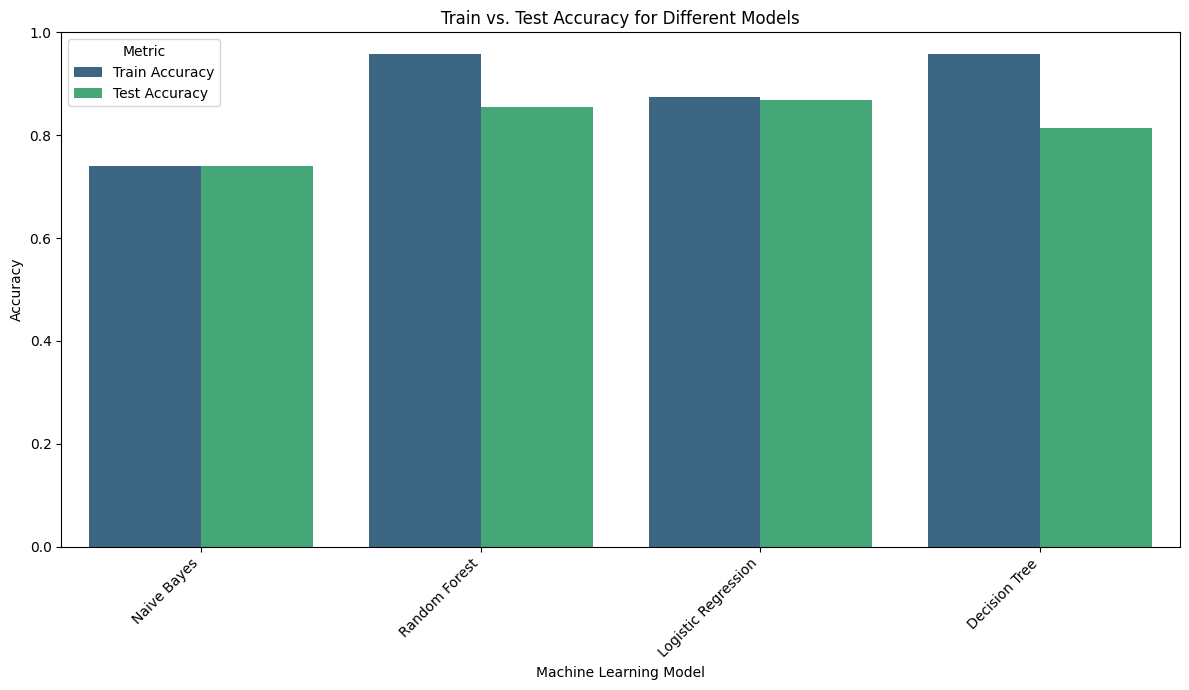

In [173]:
import matplotlib.pyplot as plt
import seaborn as sns

accuracy_data = {
    'Model': ['Naive Bayes', 'Random Forest', 'Logistic Regression', 'Decision Tree'],
    'Train Accuracy': [accuracy_train_nb, accuracy_train_rf, accuracy_train_lr, accuracy_train_dt],
    'Test Accuracy': [accuracy_test_nb, accuracy_test_rf, accuracy_test_lr, accuracy_test_dt]
}
accuracy_df = pd.DataFrame(accuracy_data)


accuracy_melted = accuracy_df.melt(id_vars='Model', var_name='Metric', value_name='Accuracy')

plt.figure(figsize=(12, 7))
sns.barplot(x='Model', y='Accuracy', hue='Metric', data=accuracy_melted, palette='viridis')
plt.title('Train vs. Test Accuracy for Different Models')
plt.ylabel('Accuracy')
plt.xlabel('Machine Learning Model')
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Summary: Logistic Regression is the best model amoung of them. Testing accuracy on this model has the highest accuracy on 0.8692181069958848